## Notebook for plotting log2FC boxplots for subset of controls 
- url: http://localhost:8888/tree?token=19656ab27fbdcce014c897e49899de41ed84287591389a1a

In [13]:
# imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [90]:
# read data in and investigate counts and labels (standard config)
rep1_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/experiments/run1counts_run2Assignment_NoDupAss/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_1_merged_assigned_counts.tsv.gz"
rep2_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/experiments/run1counts_run2Assignment_NoDupAss/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_2_merged_assigned_counts.tsv.gz"
rep3_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/experiments/run1counts_run2Assignment_NoDupAss/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_3_merged_assigned_counts.tsv.gz"
label_path = "/fast/groups/ag_kircher/MPRA/IGVF_Y1_design/resources/association_data/design_no_duplicates_sequence_and_header_label.tsv"
count_rep1 = pd.read_csv(rep1_path, sep="\t")
count_rep1["replicate"] = "rep1"
count_rep1.head()
count_rep2 = pd.read_csv(rep2_path, sep="\t")
count_rep2["replicate"] = "rep2" 
count_rep2.head()
count_rep3 = pd.read_csv(rep3_path, sep="\t")
count_rep3["replicate"] = "rep3" 
count_rep3.head()

label_df = pd.read_csv(label_path, sep="\t")
label_df.head()


,name,label
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random


In [ ]:
# nas in 

In [91]:
# combine rep1 - rep3 count data and add replicate column
count_df = pd.concat([count_rep1, count_rep2, count_rep3])
count_df

In [94]:
count_df_label = count_df.merge(label_df, on="name", how="left")
count_df_label

,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,replicate,label
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,416,1024,0.129267,0.127521,0.986492,-0.019621,121,rep1,C_SLEA
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,379,2034,0.129547,0.278629,2.150793,1.104869,110,rep1,C_SLEA
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,250,671,0.114632,0.123304,1.075646,0.105203,82,rep1,C_SLEA
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,300,909,0.112798,0.136972,1.214310,0.280137,100,rep1,C_SLEA
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,212,505,0.132851,0.126826,0.954646,-0.066962,60,rep1,C_SLEA
...,...,...,...,...,...,...,...,...,...,...
224725,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,239,1069,0.102860,0.204044,1.983701,0.988195,84,rep3,cardiac_neuro_cava_random
224726,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,87,250,0.108455,0.138219,1.274434,0.349856,29,rep3,cardiac_neuro_cava_random
224727,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,71,104,0.082799,0.053789,0.649638,-0.622292,31,rep3,cardiac_neuro_cava_random
224728,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,376,729,0.118200,0.101638,0.859877,-0.217798,115,rep3,cardiac_neuro_cava_random


In [5]:
# investigate counts
count_rep1.head()


,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,416,1024,0.129267,0.127521,0.986492,-0.019621,121
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,379,2034,0.129547,0.278629,2.150793,1.104869,110
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,250,671,0.114632,0.123304,1.075646,0.105203,82
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,300,909,0.112798,0.136972,1.214310,0.280137,100
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,212,505,0.132851,0.126826,0.954646,-0.066962,60


In [6]:
# join labels to counts (left join) and make a boxplot and violin plot for log2 ('GC_DNase_positive_shuffeled','GC_DNase_negative_brain_shuffeled','GC_DNase_negative_blood_shuffeled')
count_rep1_label = count_rep1.merge(label_df, on="name", how="left")
count_rep1_label.head()

,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,label
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,416,1024,0.129267,0.127521,0.986492,-0.019621,121,C_SLEA
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,379,2034,0.129547,0.278629,2.150793,1.104869,110,C_SLEA
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,250,671,0.114632,0.123304,1.075646,0.105203,82,C_SLEA
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,300,909,0.112798,0.136972,1.214310,0.280137,100,C_SLEA
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,212,505,0.132851,0.126826,0.954646,-0.066962,60,C_SLEA


In [57]:

label_groups = count_rep1_label["label"].unique().tolist()
label_groups

list

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-62/ipykernel_3122649/924498213.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(alternative_labels)


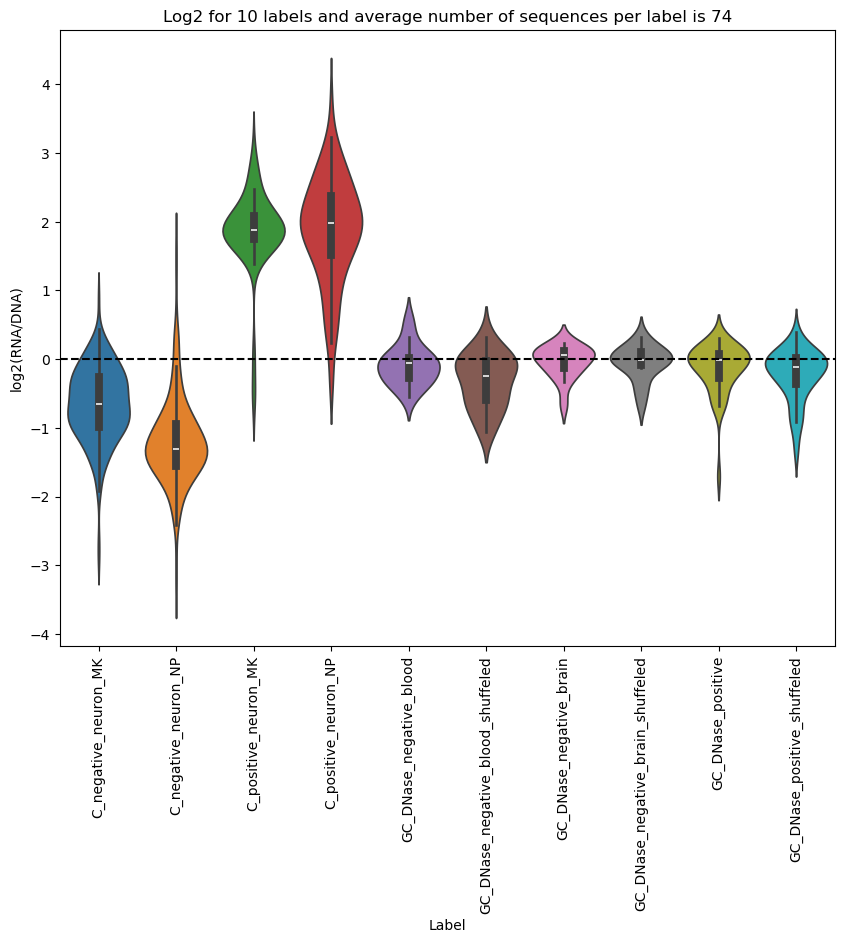

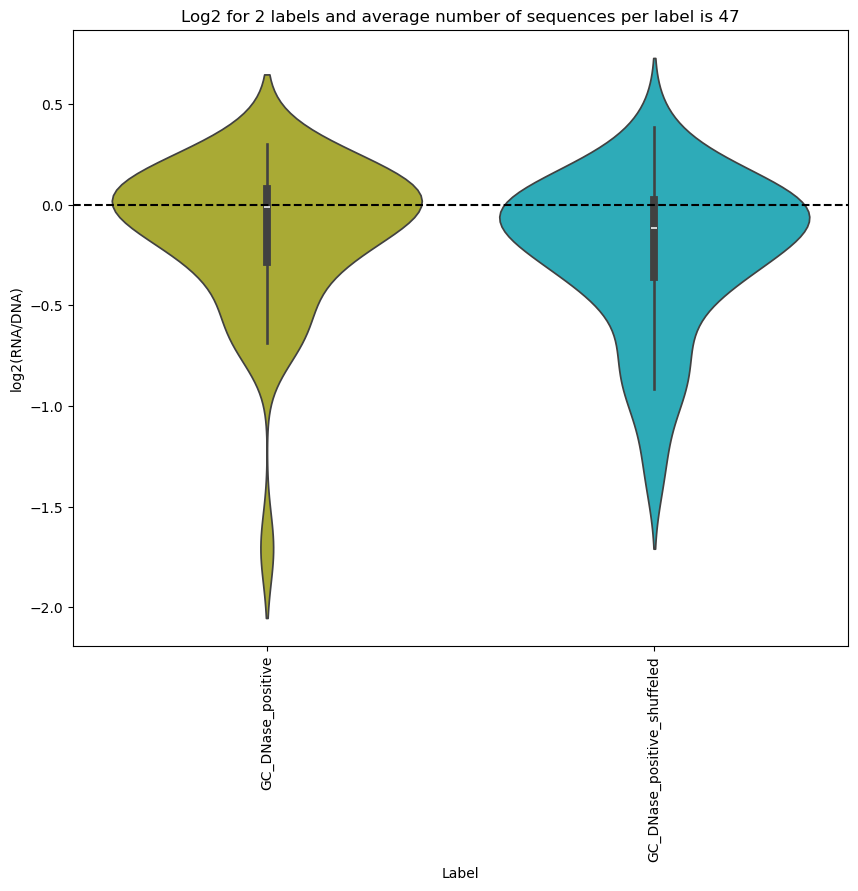

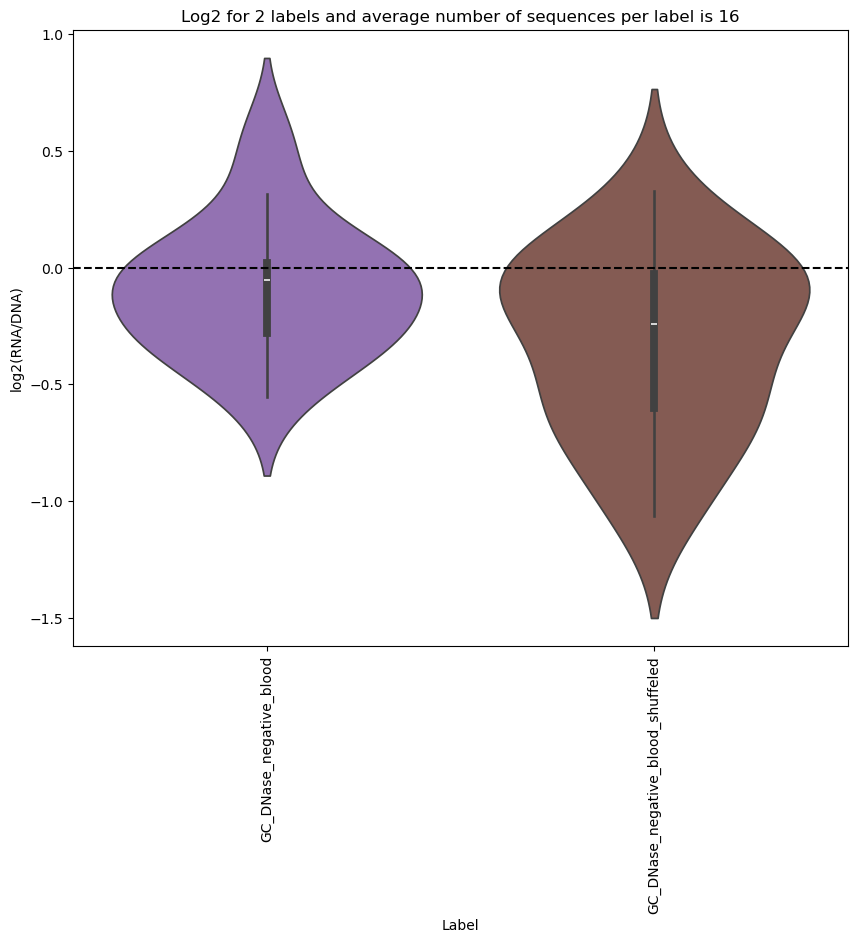

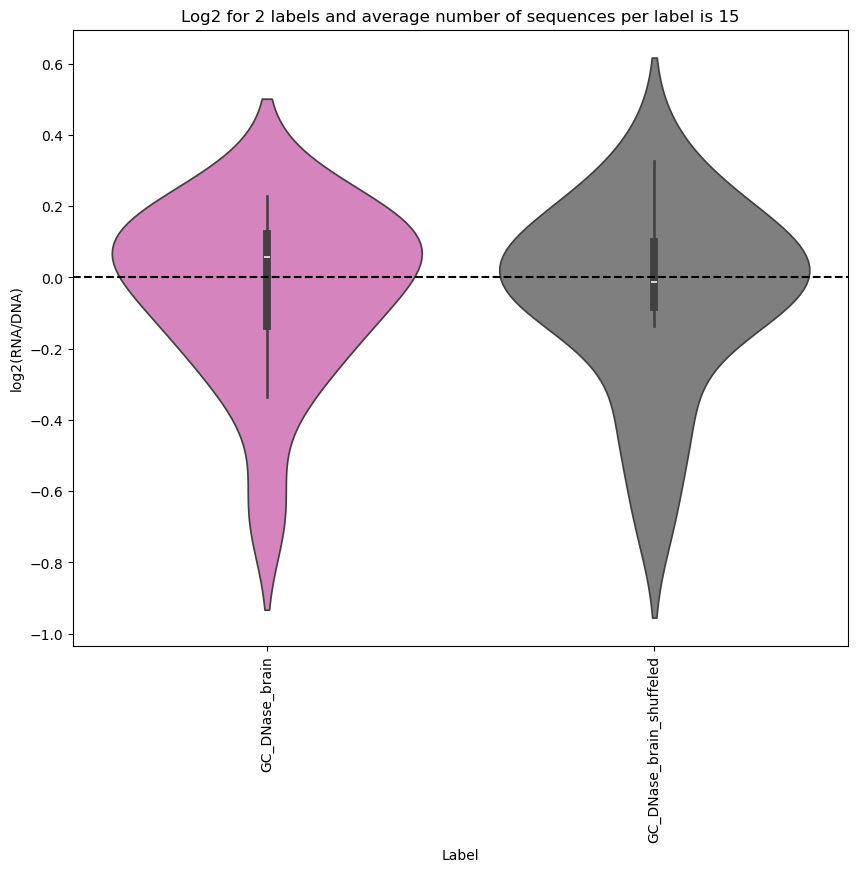

In [85]:
# function for plotting a specific list of labels as violin plot
def plot_subgroup_violin(labels_list, save_path=None, alternative_labels=None, colors=None):
    """Plot a violin plot just for a subset of labels
    @colors: dict of colors for each label
    """
    subset_rep_label_df = count_rep1_label[count_rep1_label["label"].isin(labels_list)]
    avg_seq_per_label = int(subset_rep_label_df.groupby("label").count()["name"].mean())

    fig, ax = plt.subplots(figsize=(10,8))
    ax.set_title(f'Log2 for {len(labels_list)} labels and average number of sequences per label is {avg_seq_per_label}')
    if colors:
        sns.violinplot(x=subset_rep_label_df["label"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df["label"], ax=ax, palette=colors)
    else:
        sns.violinplot(x=subset_rep_label_df["label"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df["label"], ax=ax)

    if alternative_labels:
        # add alternative labels
        ax.set_xticklabels(alternative_labels)
    plt.xticks(rotation=90)
    ax.set_xlabel('Label')
    ax.set_ylabel('log2(RNA/DNA)')
    # add line at 0 
    ax.axhline(y=0, color='black', linestyle='--')
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight') # bbox_inches='tight' to prevent cutting off labels

plot_subgroup_violin(['GC_DNase_negative_blood', 'GC_DNase_negative_blood_shuffeled',
       'GC_DNase_negative_brain', 'GC_DNase_negative_brain_shuffeled',
       'GC_DNase_positive', 'GC_DNase_positive_shuffeled', 'C_negative_neuron_NP', 'C_positive_neuron_MK', 'C_positive_neuron_NP', 'C_negative_neuron_MK'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/shuffeled_vs_not_shuffeled_controls.png", None, None)

# for keeping the colors
color_dict = {'GC_DNase_negative_blood': sns.color_palette()[0+4], 'GC_DNase_negative_blood_shuffeled': sns.color_palette()[1+4], 'GC_DNase_negative_brain': sns.color_palette()[2+4], 'GC_DNase_negative_brain_shuffeled': sns.color_palette()[3+4], 'GC_DNase_positive': sns.color_palette()[4+4], 'GC_DNase_positive_shuffeled': sns.color_palette()[5+4]}

# all DNase from encode
plot_subgroup_violin(['GC_DNase_positive', 'GC_DNase_positive_shuffeled'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/GC_DNase_positive_vs_shuffeled.png", None, color_dict)

# all from blood (negative for us)
plot_subgroup_violin(['GC_DNase_negative_blood', 'GC_DNase_negative_blood_shuffeled'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/GC_DNase_negative_blood_vs_shuffeled.png", None, color_dict)

# all from brain (for 80K positive and shuffeled: negative)
plot_subgroup_violin(['GC_DNase_negative_brain', 'GC_DNase_negative_brain_shuffeled'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/GC_DNase_negative_brain_vs_shuffeled.png", ['GC_DNase_brain', 'GC_DNase_brain_shuffeled'], color_dict)
